# 1차시 - 평가 지표

In [1]:
# Colab에서 한글 폰트 설정을 위한 코드
!apt-get update -qq # apt 패키지 리스트 업데이트
!apt-get install -y fonts-nanum # 나눔 폰트 설치

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

fontpath = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf' # 나눔바른고딕 폰트 경로
fm.fontManager.addfont(fontpath) # 폰트 매니저에 폰트 추가
plt.rcParams['font.family'] = 'NanumBarunGothic' # 기본 폰트 설정
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

print("한글 폰트 'NanumBarunGothic'이(가) 설정되었습니다.")

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 8 not upgraded.
한글 폰트 'NanumBarunGothic'이(가) 설정되었습니다.


## 라이브러리 Import

In [2]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer # 유방암 데이터셋 로드
from sklearn.model_selection import train_test_split # 훈련/테스트 데이터 분리
from sklearn.linear_model import LogisticRegression # 로지스틱 회귀 모델 (분류 모델)
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, roc_auc_score, classification_report # 평가지표들
import matplotlib.pyplot as plt # 그래프 그리기
import seaborn as sns # 더 예쁜 그래프 그리기

## 데이터 로드 및 간단한 확인

In [3]:
# breast cancer dataset
cancer = load_breast_cancer()

df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df['target'] = cancer.target

display(df.head())

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [4]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

None

## 전처리 및 분류 모델 학습

In [6]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3,
    random_state=42, stratify=y
)

# Logistic regression
model = LogisticRegression(max_iter=10000, random_state=42)
model.fit(X_train, y_train)

# 예측 수행
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1] # 양성 클래스(1)에 대한 예측 확률

print("데이터 분리 및 로지스틱 회귀 모델 학습, 예측 완료!")
print(f"테스트 데이터 정확도: {accuracy_score(y_test, y_pred):.4f}")

데이터 분리 및 로지스틱 회귀 모델 학습, 예측 완료!
테스트 데이터 정확도: 0.9474


## 혼동 행렬 (Confusion Matrix) 출력 및 TP/TN/FP/FN 값 추출



In [7]:
# 혼동 행렬 계산
conf_matrix = confusion_matrix(y_test, y_pred)
print("confusion matrix")
display(conf_matrix)

confusion matrix


array([[ 57,   7],
       [  2, 105]])

In [8]:
# 혼동 행렬의 각 요소 추출
# TN (True Negative): 실제 0을 0으로 맞게 예측 (음성으로 맞게 예측)
# FP (False Positive): 실제 0을 1로 틀리게 예측 (음성을 양성으로 잘못 예측) - 1종 오류
# FN (False Negative): 실제 1을 0으로 틀리게 예측 (양성을 음성으로 잘못 예측) - 2종 오류
# TP (True Positive): 실제 1을 1으로 맞게 예측 (양성으로 맞게 예측)

TN, FP, FN, TP = conf_matrix.ravel()
print(f"\nTP (True Positive - 진짜 양성): {TP}개 (모델이 '양성'이라고 예측했고, 실제도 '양성'인 경우. 암을 암으로 정확히 진단)")
print(f"TN (True Negative - 진짜 음성): {TN}개 (모델이 '음성'이라고 예측했고, 실제도 '음성'인 경우. 정상인을 정상으로 정확히 진단)")
print(f"FP (False Positive - 거짓 양성): {FP}개 (모델이 '양성'이라고 예측했지만, 실제는 '음성'인 경우. 정상인을 암이라고 잘못 진단 - 오진)")
print(f"FN (False Negative - 거짓 음성): {FN}개 (모델이 '음성'이라고 예측했지만, 실제는 '양성'인 경우. 암 환자를 정상이라고 잘못 진단 - 오진)")


TP (True Positive - 진짜 양성): 105개 (모델이 '양성'이라고 예측했고, 실제도 '양성'인 경우. 암을 암으로 정확히 진단)
TN (True Negative - 진짜 음성): 57개 (모델이 '음성'이라고 예측했고, 실제도 '음성'인 경우. 정상인을 정상으로 정확히 진단)
FP (False Positive - 거짓 양성): 7개 (모델이 '양성'이라고 예측했지만, 실제는 '음성'인 경우. 정상인을 암이라고 잘못 진단 - 오진)
FN (False Negative - 거짓 음성): 2개 (모델이 '음성'이라고 예측했지만, 실제는 '양성'인 경우. 암 환자를 정상이라고 잘못 진단 - 오진)


## 혼동 행렬 시각화 (Heatmap)

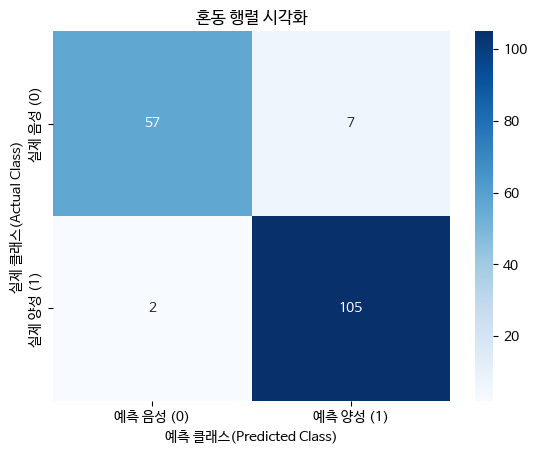

In [9]:
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['예측 음성 (0)', '예측 양성 (1)'],
            yticklabels=['실제 음성 (0)', '실제 양성 (1)'])
plt.xlabel('예측 클래스(Predicted Class)')
plt.ylabel('실제 클래스(Actual Class)')
plt.title('혼동 행렬 시각화')
plt.show()

## Precision / Recall / F1-Score / Specificity 계산 및 출력


In [10]:
# 1. 정밀도(Precision)
precision = TP / (TP + FP) if (TP + FP) > 0 else 0

print(f"--- 정밀도 (Precision) ---")
print(f"직접 계산한 정밀도: {precision:.4f}")
print(f"sklearn으로 계산한 정밀도: {precision_score(y_test, y_pred):.4f}")
print("  -> 모델이 '유방암'이라고 예측한 환자들 중에서 실제로 유방암인 환자의 비율입니다.")
print("  -> 정밀도가 높다는 것은 '정상'인데 '유방암'이라고 잘못 진단(FP)하는 오진을 줄이는 데 중요합니다.")

--- 정밀도 (Precision) ---
직접 계산한 정밀도: 0.9375
sklearn으로 계산한 정밀도: 0.9375
  -> 모델이 '유방암'이라고 예측한 환자들 중에서 실제로 유방암인 환자의 비율입니다.
  -> 정밀도가 높다는 것은 '정상'인데 '유방암'이라고 잘못 진단(FP)하는 오진을 줄이는 데 중요합니다.


In [11]:
# 2. 재현율(Recall)
recall = TP / (TP + FN) if (TP + FN) > 0 else 0

print(f"\n--- 재현율 (Recall) ---")
print(f"직접 계산한 재현율: {recall:.4f}")
print(f"sklearn으로 계산한 재현율: {recall_score(y_test, y_pred):.4f}")
print("  -> 실제 유방암 환자들 중에서 모델이 유방암이라고 정확히 예측한 환자의 비율입니다.")
print("  -> 재현율이 높다는 것은 실제 '유방암'인데 '정상'이라고 잘못 진단(FN)하는 오진을 줄이는 데 중요합니다.")


--- 재현율 (Recall) ---
직접 계산한 재현율: 0.9813
sklearn으로 계산한 재현율: 0.9813
  -> 실제 유방암 환자들 중에서 모델이 유방암이라고 정확히 예측한 환자의 비율입니다.
  -> 재현율이 높다는 것은 실제 '유방암'인데 '정상'이라고 잘못 진단(FN)하는 오진을 줄이는 데 중요합니다.


In [13]:
# 3. F1-Score
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f"\n--- F1-Score ---")
print(f"직접 계산한 F1-Score: {f1:.4f}")
print(f"sklearn으로 계산한 F1-Score: {f1_score(y_test, y_pred):.4f}")
print("  -> 정밀도와 재현율이 모두 중요한 상황에서 모델의 균형적인 성능을 나타내는 지표입니다.")
print("  -> 어느 한쪽만 높고 다른 쪽이 낮을 경우 F1-Score는 낮아지므로, 두 지표를 모두 고려할 때 유용합니다.")


--- F1-Score ---
직접 계산한 F1-Score: 0.9589
sklearn으로 계산한 F1-Score: 0.9589
  -> 정밀도와 재현율이 모두 중요한 상황에서 모델의 균형적인 성능을 나타내는 지표입니다.
  -> 어느 한쪽만 높고 다른 쪽이 낮을 경우 F1-Score는 낮아지므로, 두 지표를 모두 고려할 때 유용합니다.


In [14]:
# 4. 특이도(Specificity)
specificity = TN / (TN + FP) if (TN + FP) > 0 else 0

print(f"\n--- 특이도 (Specificity) ---")
print(f"직접 계산한 특이도: {specificity:.4f}")
print(f"sklearn으로 계산한 특이도: {recall_score(y_test, y_pred, pos_label=0):.4f}")
print("  -> 실제로 '정상'인 사람들 중에서 모델이 '정상'이라고 정확히 예측한 환자의 비율입니다.")
print("  -> 특이도가 높다는 것은 실제 '정상'인데 '유방암'이라고 잘못 진단(FP)하는 오진을 줄이는 데 중요합니다.")


--- 특이도 (Specificity) ---
직접 계산한 특이도: 0.8906
sklearn으로 계산한 특이도: 0.8906
  -> 실제로 '정상'인 사람들 중에서 모델이 '정상'이라고 정확히 예측한 환자의 비율입니다.
  -> 특이도가 높다는 것은 실제 '정상'인데 '유방암'이라고 잘못 진단(FP)하는 오진을 줄이는 데 중요합니다.


## Classification Report 출력

In [15]:
# classification_report 함수를 사용하여 모든 주요 평가지표를 한 번에 확인합니다.
from sklearn.metrics import classification_report

print("--- 분류 모델 성능 요약 보고서 (Classification Report) ---")
print(classification_report(y_test, y_pred, target_names=cancer.target_names))

print("----------------------------------------------------------")
print("Classification Report 출력 완료!")
print("\n[ 용어 설명 ]")
print("1. support: 각 클래스(malignant, benign)에 속하는 실제 데이터의 개수입니다.")
print("2. accuracy: 전체 데이터 중에서 모델이 올바르게 예측한 비율(정확도)입니다.")
print("3. macro avg: 모든 클래스의 지표를 동일한 비중으로 단순 평균낸 값입니다.")
print("4. weighted avg: 데이터 개수(support)가 많은 클래스에 더 높은 가중치를 주어 평균낸 값입니다.")
print("   -> 클래스 간 불균형이 있을 때 'weighted avg'가 더 신뢰할 만한 지표가 됩니다.")

--- 분류 모델 성능 요약 보고서 (Classification Report) ---
              precision    recall  f1-score   support

   malignant       0.97      0.89      0.93        64
      benign       0.94      0.98      0.96       107

    accuracy                           0.95       171
   macro avg       0.95      0.94      0.94       171
weighted avg       0.95      0.95      0.95       171

----------------------------------------------------------
Classification Report 출력 완료!

[ 용어 설명 ]
1. support: 각 클래스(malignant, benign)에 속하는 실제 데이터의 개수입니다.
2. accuracy: 전체 데이터 중에서 모델이 올바르게 예측한 비율(정확도)입니다.
3. macro avg: 모든 클래스의 지표를 동일한 비중으로 단순 평균낸 값입니다.
4. weighted avg: 데이터 개수(support)가 많은 클래스에 더 높은 가중치를 주어 평균낸 값입니다.
   -> 클래스 간 불균형이 있을 때 'weighted avg'가 더 신뢰할 만한 지표가 됩니다.


## AUC-ROC 계산 및 그래프 출력

AUC-ROC 점수: 0.9889018691588785


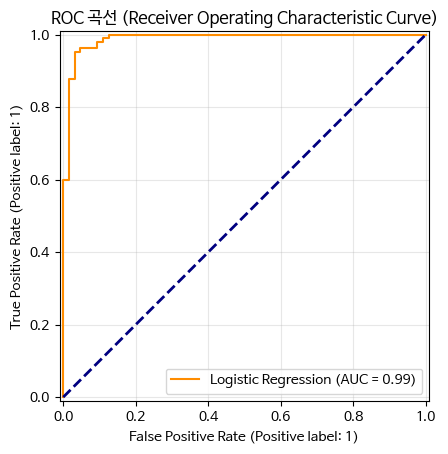

In [16]:
from sklearn.metrics import RocCurveDisplay, roc_curve, roc_auc_score

auc_score = roc_auc_score(y_test, y_pred_proba)

print(f'AUC-ROC 점수: {auc_score}')

RocCurveDisplay.from_predictions(y_test, y_pred_proba, name='Logistic Regression',
                                 color='darkorange')
# 기준선(Random) 추가 및 마무리 설정
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier (AUC = 0.50)')
plt.grid(True, alpha=0.3)
plt.title('ROC 곡선 (Receiver Operating Characteristic Curve)')
plt.show()

# 2차시 LLM을 활용한 데이터 탐색

In [18]:
# https://www.kaggle.com/datasets/sulianova/cardiovascular-disease-dataset
import os
import kagglehub

# Download latest version
path = kagglehub.dataset_download(
    "sulianova/cardiovascular-disease-dataset")

# 다운로드된 경로에서 파일 확인
print(os.listdir(path))

# CSV 파일 불러오기 (세미콜론 구분자)
df = pd.read_csv(os.path.join(path, 'cardio_train.csv'), sep=';')

# 데이터 확인
print(df.shape)
df.info()

Using Colab cache for faster access to the 'cardiovascular-disease-dataset' dataset.
['cardio_train.csv']
(70000, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [19]:
numeric_cols = ['age', 'height', 'weight', 'ap_hi', 'ap_lo']

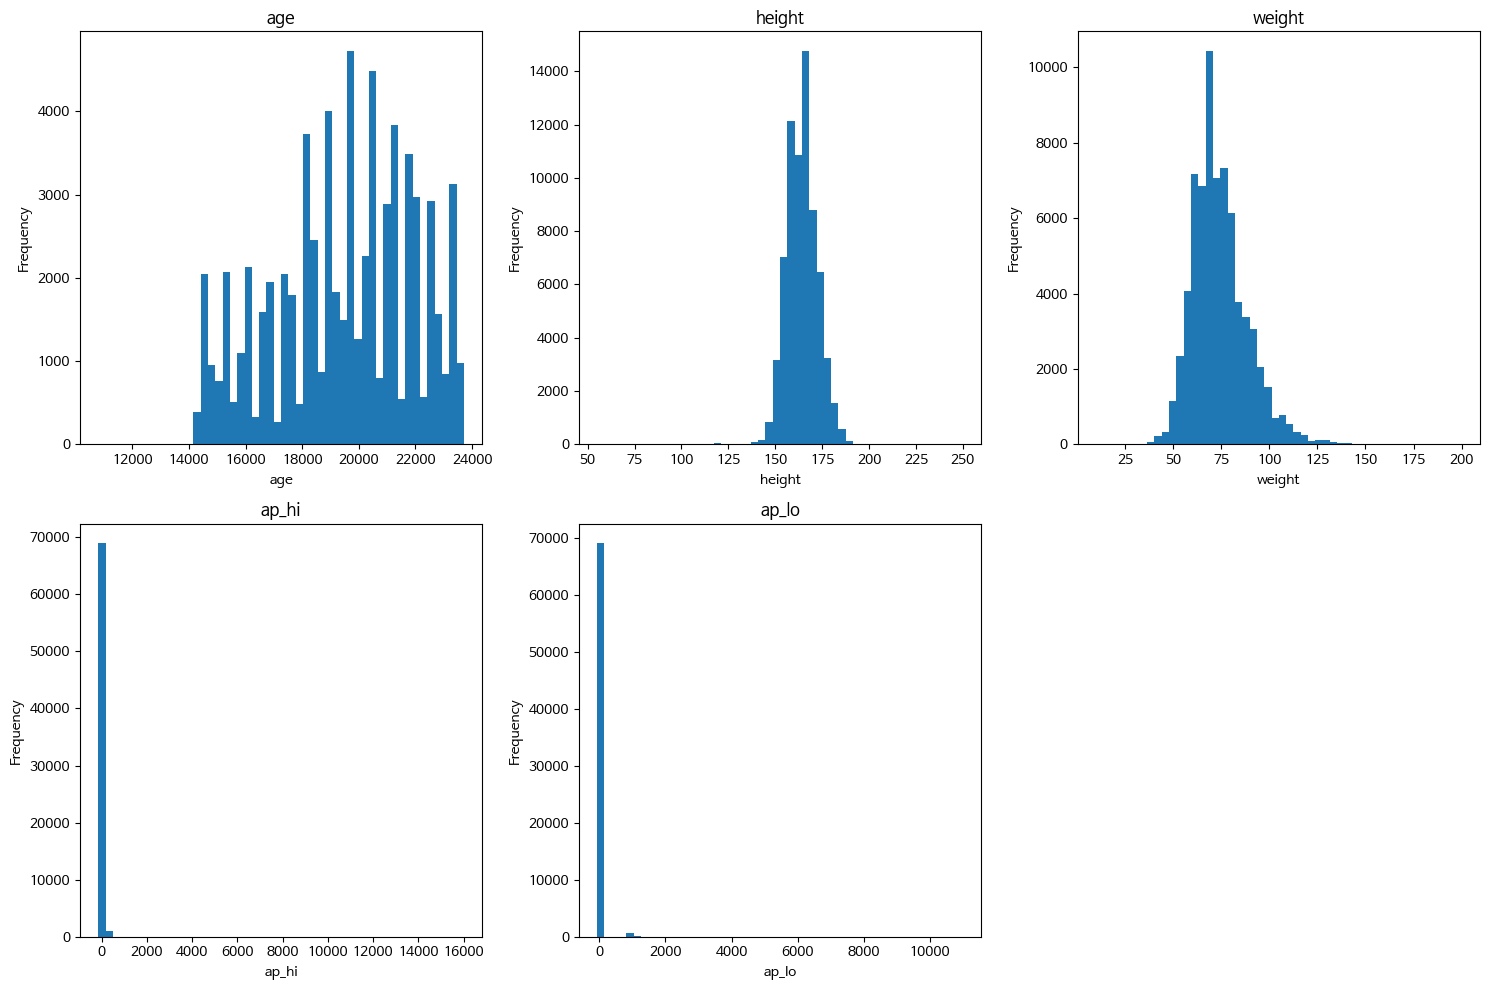

In [20]:
# 3) 히스토그램 시각화 (기본 버전)
plt.figure(figsize=(15, 10))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)
    plt.hist(df[col], bins=50)
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

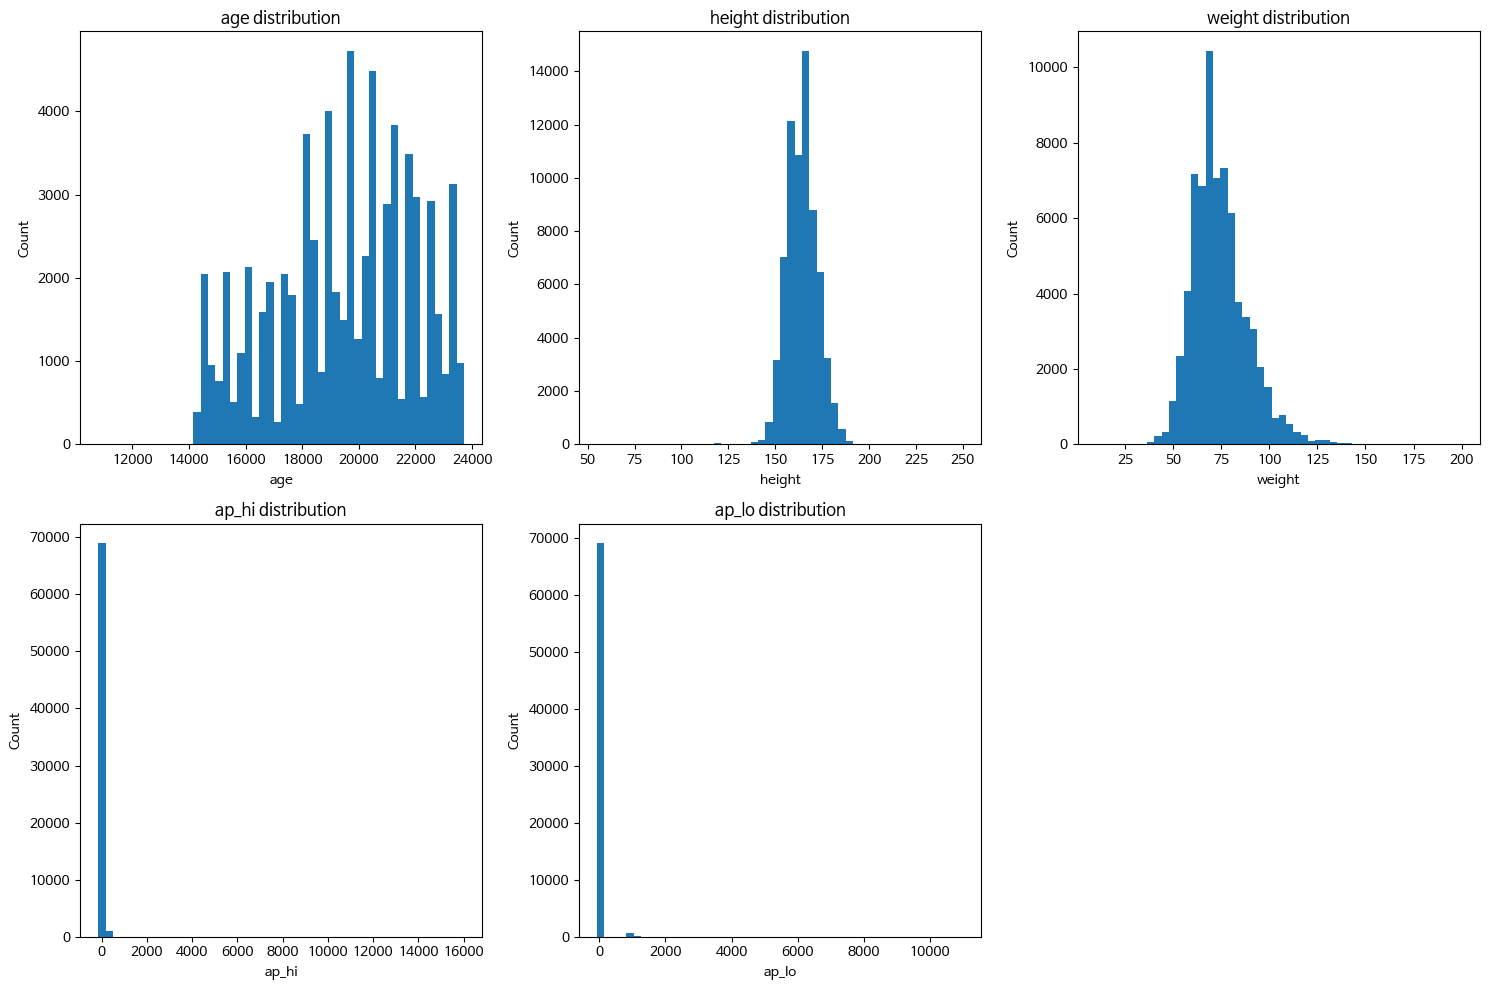

In [21]:
# 4) 개선 버전 (이상치 확인에 유리)
plt.figure(figsize=(15, 10))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)

    # 이상치 영향 줄이기 (선택)
    data = df[col]

    plt.hist(data, bins=50)
    plt.title(f'{col} distribution')
    plt.xlabel(col)
    plt.ylabel('Count')

plt.tight_layout()
plt.show()

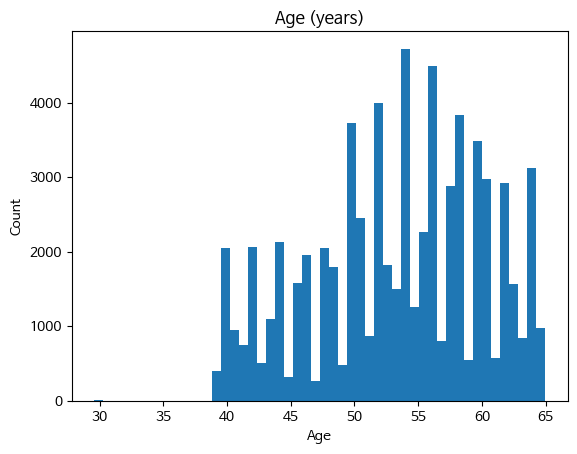

In [22]:
# 5) 추가 추천 (age 변환 후 시각화)
df['age_year'] = df['age'] / 365

plt.hist(df['age_year'], bins=50)
plt.title('Age (years)')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

In [23]:
# 범주형 변수 처리
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 2) 범주형 변수 정의
categorical_cols = [
    'gender', 'cholesterol', 'gluc',
    'smoke', 'alco', 'active', 'cardio'
]

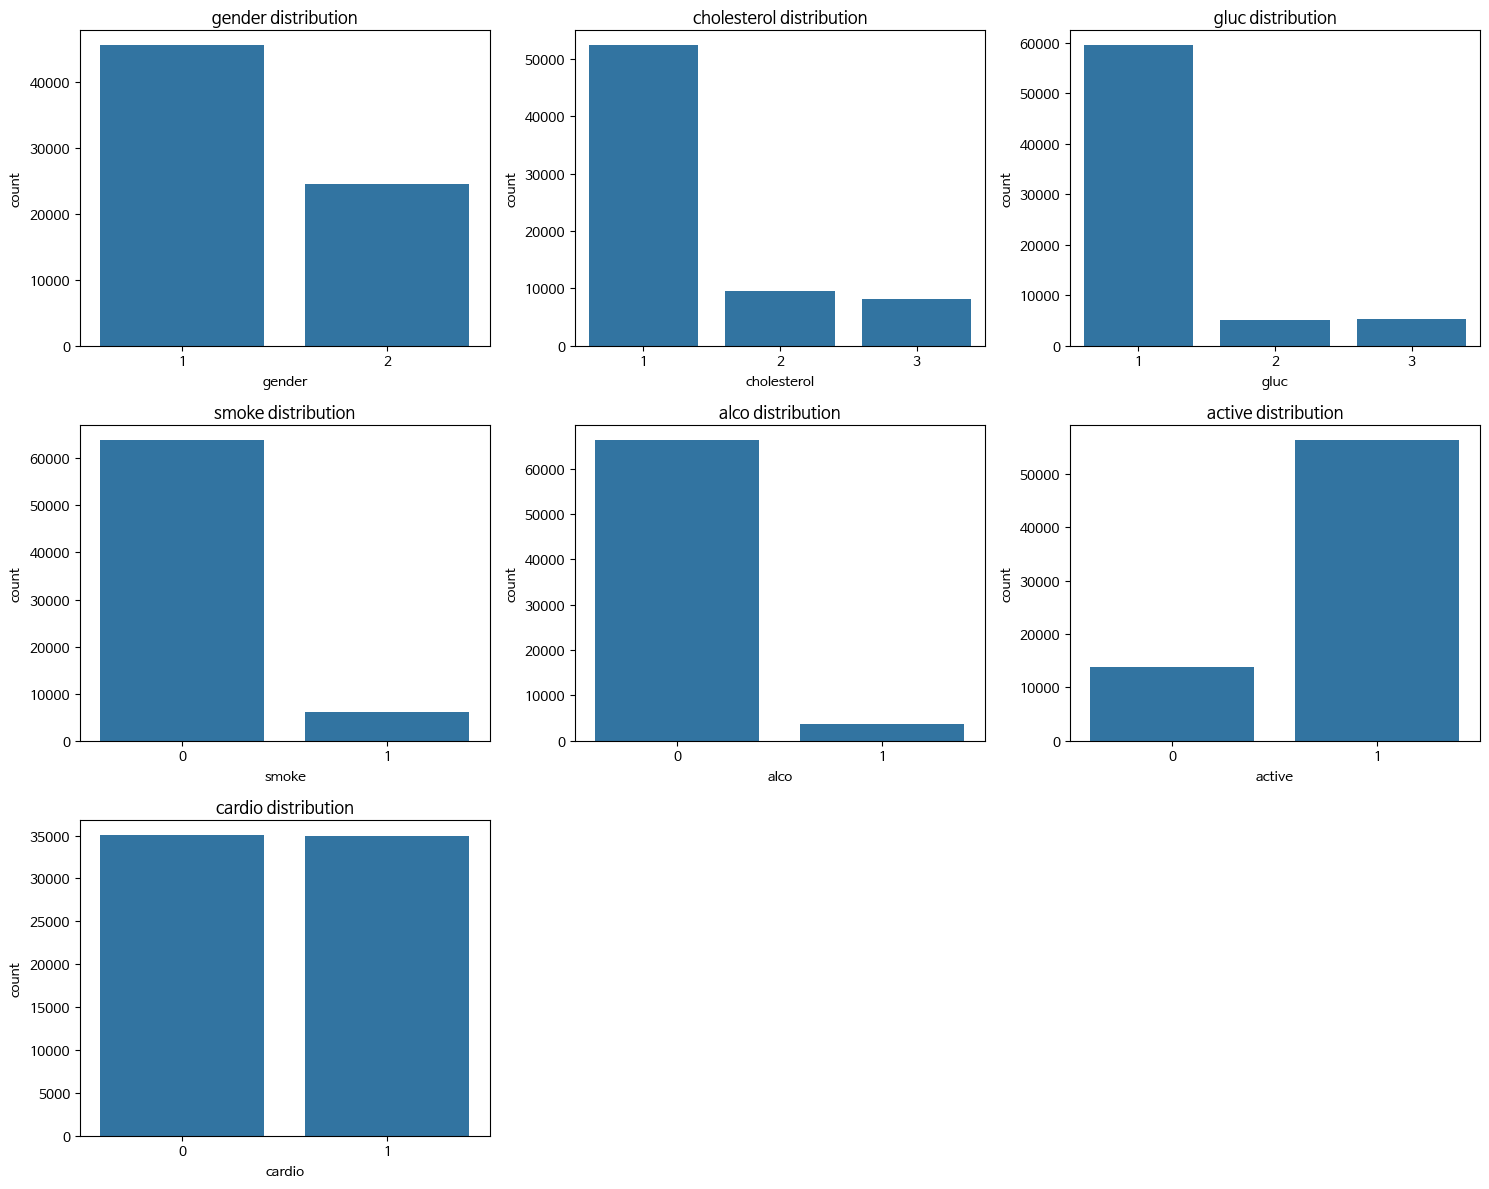

In [24]:
# 3) 기본 count plot (한 번에 보기)
plt.figure(figsize=(15, 12))

for i, col in enumerate(categorical_cols, 1):
    plt.subplot(3, 3, i)
    sns.countplot(x=col, data=df)
    plt.title(f'{col} distribution')

plt.tight_layout()
plt.show()

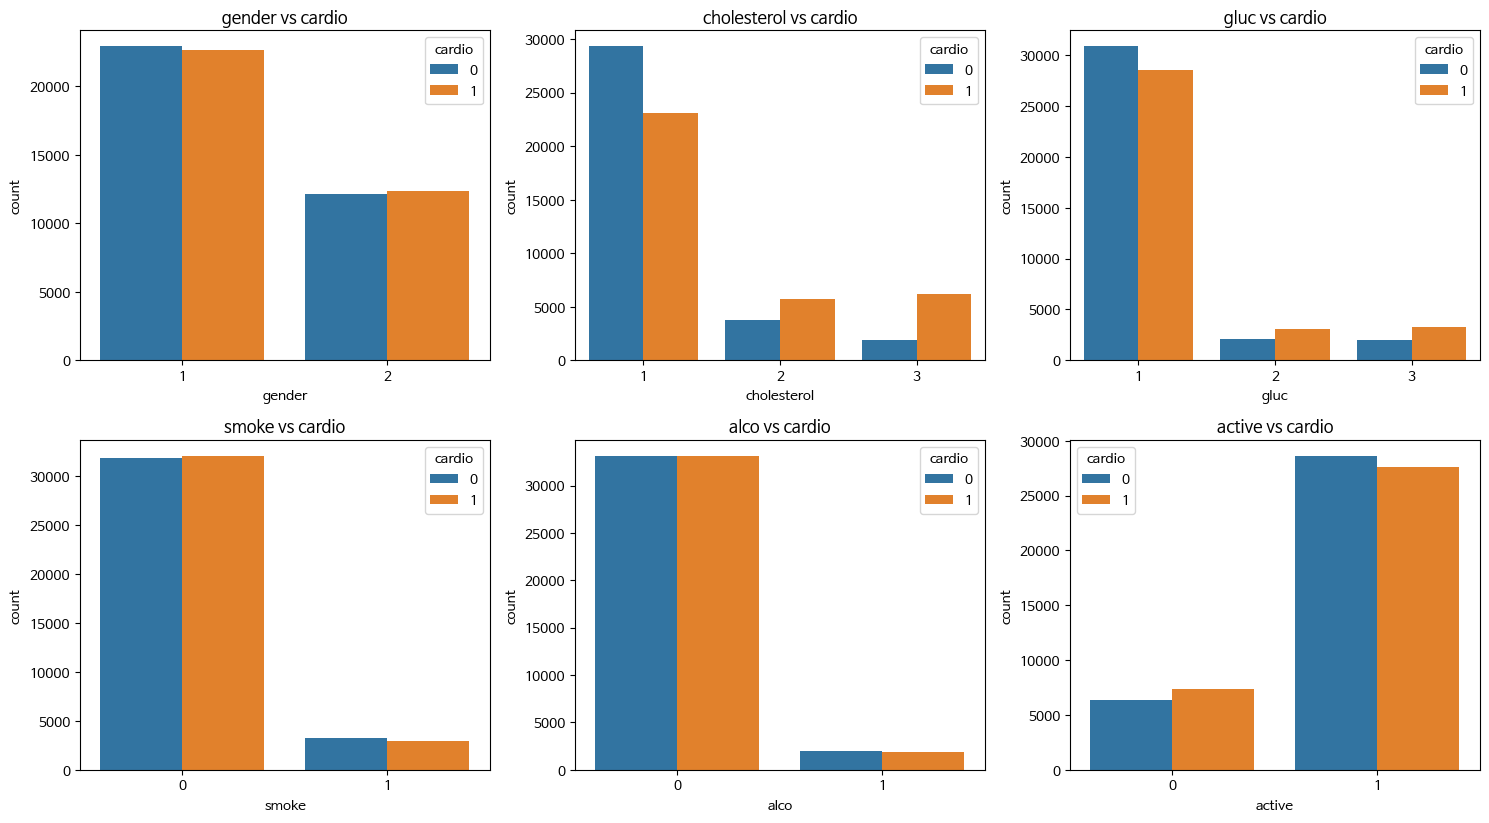

In [25]:
# 4) 타겟(cardio) 기준 분포 확인 (추천 ⭐)
plt.figure(figsize=(15, 12))

for i, col in enumerate(categorical_cols[:-1], 1):  # cardio 제외
    plt.subplot(3, 3, i)
    sns.countplot(x=col, hue='cardio', data=df)
    plt.title(f'{col} vs cardio')

plt.tight_layout()
plt.show()

In [26]:
# 5) 비율 기반 시각화 (정규화)
for col in categorical_cols:
    print(f"\n{col} 비율")
    print(df[col].value_counts(normalize=True))


gender 비율
gender
1    0.650429
2    0.349571
Name: proportion, dtype: float64

cholesterol 비율
cholesterol
1    0.748357
2    0.136414
3    0.115229
Name: proportion, dtype: float64

gluc 비율
gluc
1    0.849700
3    0.076157
2    0.074143
Name: proportion, dtype: float64

smoke 비율
smoke
0    0.911871
1    0.088129
Name: proportion, dtype: float64

alco 비율
alco
0    0.946229
1    0.053771
Name: proportion, dtype: float64

active 비율
active
1    0.803729
0    0.196271
Name: proportion, dtype: float64

cardio 비율
cardio
0    0.5003
1    0.4997
Name: proportion, dtype: float64


# 3차시 LLM을 활용한 데이터 모델링 및 해석

In [27]:
# 결측치 확인
df.isnull().sum()

,0
id,0
age,0
gender,0
height,0
weight,0
ap_hi,0
ap_lo,0
cholesterol,0
gluc,0
smoke,0


In [28]:
df.describe()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_year
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700,53.339358
std,28851.302323,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003,6.759594
min,0.000000,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,29.583562
25%,25006.750000,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,48.394521
50%,50001.500000,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,53.980822
75%,74889.250000,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000,58.430137
max,99999.000000,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000,64.967123


## 이상치 처리

In [29]:
# 방법 1: 컬럼별 IQR 필터링
import pandas as pd

# 데이터 로드
# df = pd.read_csv('your_dataset.csv')

# 이상치 처리 대상 컬럼
cols = ['height', 'weight', 'ap_hi', 'ap_lo', 'BMI', 'pulse_pressure']

def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    print(f"{column}: [{lower:.2f}, {upper:.2f}]")

    return df[(df[column] >= lower) & (df[column] <= upper)]

# 순차 적용
for col in cols:
    df = remove_outliers_iqr(df, col)

print("이상치 제거 후 데이터 크기:", df.shape)

height: [142.50, 186.50]
weight: [39.50, 107.50]
ap_hi: [90.00, 170.00]
ap_lo: [65.00, 105.00]


KeyError: 'BMI'

In [30]:
# 수정된 전체 코드
import pandas as pd

# 데이터 로드
# df = pd.read_csv('your_dataset.csv')

# -----------------------------
# 1. 파생 변수 생성 (필수)
# -----------------------------
df['BMI'] = df['weight'] / (df['height'] / 100) ** 2
df['pulse_pressure'] = df['ap_hi'] - df['ap_lo']

# -----------------------------
# 2. 이상치 처리 대상 컬럼
# -----------------------------
cols = ['height', 'weight', 'ap_hi', 'ap_lo', 'BMI', 'pulse_pressure']

# -----------------------------
# 3. IQR 함수
# -----------------------------
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    print(f"{column}: [{lower:.2f}, {upper:.2f}]")

    return df[(df[column] >= lower) & (df[column] <= upper)]

# -----------------------------
# 4. 순차 적용
# -----------------------------
for col in cols:
    df = remove_outliers_iqr(df, col)

print("이상치 제거 후 데이터 크기:", df.shape)

height: [142.50, 186.50]
weight: [41.00, 105.00]
ap_hi: [90.00, 170.00]
ap_lo: [65.00, 105.00]
BMI: [15.06, 38.57]
pulse_pressure: [25.00, 65.00]
이상치 제거 후 데이터 크기: (57433, 16)


In [31]:
# =========================
# 0. 라이브러리
# =========================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# =========================
# 1. 데이터 로드
# =========================
# df = pd.read_csv('your_dataset.csv')

print("초기 데이터 크기:", df.shape)

# =========================
# 2. 불필요 컬럼 제거
# =========================
if 'id' in df.columns:
    df = df.drop(columns=['id'])

# =========================
# 3. 파생 변수 생성
# =========================

# 나이 변환 (일 → 년)
df['age_year'] = df['age'] / 365

# BMI
df['BMI'] = df['weight'] / (df['height'] / 100) ** 2

# pulse pressure
df['pulse_pressure'] = df['ap_hi'] - df['ap_lo']

# =========================
# 4. 이상치 제거 (임상 기준 + IQR 혼합)
# =========================

# (1) 기본 범위 필터
df = df[(df['height'] >= 120) & (df['height'] <= 220)]
df = df[(df['weight'] >= 30) & (df['weight'] <= 200)]
df = df[(df['age_year'] > 0) & (df['age_year'] < 120)]

# (2) 혈압
df = df[(df['ap_hi'] >= 80) & (df['ap_hi'] <= 250)]
df = df[(df['ap_lo'] >= 40) & (df['ap_lo'] <= 150)]
df = df[df['ap_hi'] > df['ap_lo']]

# (3) BMI
df = df[(df['BMI'] >= 10) & (df['BMI'] <= 60)]

# (4) pulse pressure
df = df[df['pulse_pressure'] > 0]

# =========================
# 5. IQR 기반 추가 정제
# =========================

def iqr_filter(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[col] >= lower) & (df[col] <= upper)]

iqr_cols = ['height', 'weight', 'ap_hi', 'ap_lo', 'BMI', 'pulse_pressure']

for col in iqr_cols:
    df = iqr_filter(df, col)

print("이상치 제거 후:", df.shape)

# =========================
# 6. 이진 변수 검증
# =========================
binary_cols = ['smoke', 'alco', 'active', 'cardio']

for col in binary_cols:
    df = df[df[col].isin([0, 1])]

# =========================
# 7. 범주형 변수 처리
# =========================

# gender → 이진화 (1,2 → 0,1)
df['gender'] = df['gender'] - 1

# cholesterol, gluc → one-hot
df = pd.get_dummies(df, columns=['cholesterol', 'gluc'], drop_first=True)

# =========================
# 8. Feature / Target 분리
# =========================
X = df.drop(columns=['cardio'])
y = df['cardio']

# =========================
# 9. Train/Test Split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================
# 10. 스케일링 (수치형만)
# =========================

numeric_cols = ['age_year', 'height', 'weight', 'ap_hi', 'ap_lo', 'BMI', 'pulse_pressure']

scaler = StandardScaler()

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

# =========================
# 11. 최종 확인
# =========================
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("타겟 분포:\n", y.value_counts(normalize=True))

초기 데이터 크기: (57433, 16)
이상치 제거 후: (22388, 15)
Train shape: (17910, 16)
Test shape: (4478, 16)
타겟 분포:
 cardio
0    0.649678
1    0.350322
Name: proportion, dtype: float64


## LLM을 활용한 모델링

In [32]:
# ==============================
# 1. 라이브러리 불러오기
# ==============================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# ==============================
# 2. 데이터 불러오기
# ==============================
# 예시:
# df = pd.read_csv('/content/preprocessed_cardio_data.csv')

# Colab에서 파일 업로드 후 사용하려면:
# from google.colab import files
# uploaded = files.upload()
# df = pd.read_csv('파일명.csv')

# df = pd.read_csv('/content/preprocessed_cardio_data.csv')

# ==============================
# 3. 입력 변수(X), 타겟 변수(y) 분리
# ==============================
feature_cols = [
    'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
    'cholesterol', 'gluc', 'smoke', 'alco', 'active'
]

X = df[feature_cols]
y = df['cardio']

# ==============================
# 4. 학습용/테스트용 데이터 분할
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train 분포:\n", y_train.value_counts(normalize=True))
print("y_test 분포:\n", y_test.value_counts(normalize=True))

# ==============================
# 5. Random Forest 모델 생성 및 학습
# ==============================
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# ==============================
# 6. 예측
# ==============================
y_pred = rf_model.predict(X_test)

# ==============================
# 7. 성능 평가 지표 계산
# ==============================
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

# 혼동행렬
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

# 민감도(Sensitivity) = Recall
sensitivity = tp / (tp + fn) if (tp + fn) != 0 else 0

# 특이도(Specificity)
specificity = tn / (tn + fp) if (tn + fp) != 0 else 0

# ==============================
# 8. 결과 출력
# ==============================
print("\n===== Random Forest 분류 성능 =====")
print(f"정확도(Accuracy):   {accuracy:.4f}")
print(f"정밀도(Precision): {precision:.4f}")
print(f"재현율(Recall):    {recall:.4f}")
print(f"F1 Score:          {f1:.4f}")
print(f"민감도(Sensitivity): {sensitivity:.4f}")
print(f"특이도(Specificity): {specificity:.4f}")

print("\n===== 혼동행렬(Confusion Matrix) =====")
print(cm)

print("\n[혼동행렬 해석]")
print(f"TN (True Negative):  {tn}")
print(f"FP (False Positive): {fp}")
print(f"FN (False Negative): {fn}")
print(f"TP (True Positive):  {tp}")

print("\n===== Classification Report =====")
print(classification_report(y_test, y_pred, digits=4, zero_division=0))

KeyError: "['cholesterol', 'gluc'] not in index"

In [33]:
print(df.columns.tolist())

['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'smoke', 'alco', 'active', 'cardio', 'age_year', 'BMI', 'pulse_pressure', 'cholesterol_2', 'cholesterol_3', 'gluc_2', 'gluc_3']


In [34]:
# 수정된 전체 코드
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# 데이터가 이미 로드되어 있다고 가정
# df = pd.read_csv('/content/preprocessed_cardio_data.csv')

# 현재 컬럼 확인
# print("현재 컬럼 목록:")
# print(df.columns.tolist())

# 전처리된 데이터셋 기준 feature 선택
feature_cols = [
    'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
    'smoke', 'alco', 'active',
    'cholesterol_2', 'cholesterol_3',
    'gluc_2', 'gluc_3'
]

# 없는 컬럼 점검
missing_cols = [col for col in feature_cols if col not in df.columns]
print("없는 컬럼:", missing_cols)

# 입력 변수, 타겟 변수 분리
X = df[feature_cols]
y = df['cardio']

# 학습/테스트 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

# 모델 학습
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# 예측
y_pred = rf_model.predict(X_test)

# 평가 지표
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn) if (tp + fn) != 0 else 0
specificity = tn / (tn + fp) if (tn + fp) != 0 else 0

print("\n===== Random Forest 분류 성능 =====")
print(f"정확도(Accuracy): {accuracy:.4f}")
print(f"정밀도(Precision): {precision:.4f}")
print(f"재현율(Recall): {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"민감도(Sensitivity): {sensitivity:.4f}")
print(f"특이도(Specificity): {specificity:.4f}")

print("\n===== 혼동행렬(Confusion Matrix) =====")
print(cm)

print("\n[혼동행렬 해석]")
print(f"TN (True Negative): {tn}")
print(f"FP (False Positive): {fp}")
print(f"FN (False Negative): {fn}")
print(f"TP (True Positive): {tp}")

print("\n===== Classification Report =====")
print(classification_report(y_test, y_pred, digits=4, zero_division=0))

없는 컬럼: []
X_train shape: (17910, 13)
X_test shape: (4478, 13)

===== Random Forest 분류 성능 =====
정확도(Accuracy): 0.6449
정밀도(Precision): 0.4906
재현율(Recall): 0.3499
F1 Score: 0.4085
민감도(Sensitivity): 0.3499
특이도(Specificity): 0.8041

===== 혼동행렬(Confusion Matrix) =====
[[2339  570]
 [1020  549]]

[혼동행렬 해석]
TN (True Negative): 2339
FP (False Positive): 570
FN (False Negative): 1020
TP (True Positive): 549

===== Classification Report =====
              precision    recall  f1-score   support

           0     0.6963    0.8041    0.7463      2909
           1     0.4906    0.3499    0.4085      1569

    accuracy                         0.6449      4478
   macro avg     0.5935    0.5770    0.5774      4478
weighted avg     0.6243    0.6449    0.6280      4478



## LLM을 활용한 모델 개선

In [35]:
# 개선 후 평가지표 비교 코드
# ==============================
# 1. 라이브러리
# ==============================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix
)

# ==============================
# 2. 데이터 준비
# ==============================
# df = pd.read_csv('/content/preprocessed_cardio_data.csv')

# feature 구성 (원-핫 여부에 따라 수정 필요)
base_features = ['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'smoke', 'alco', 'active']

if 'cholesterol' in df.columns:
    extra_features = ['cholesterol', 'gluc']
else:
    extra_features = [col for col in df.columns if col.startswith('cholesterol_') or col.startswith('gluc_')]

feature_cols = base_features + extra_features

X = df[feature_cols]
y = df['cardio']

# train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ==============================
# 3. 기존 모델 (baseline)
# ==============================
model_base = RandomForestClassifier(random_state=42)
model_base.fit(X_train, y_train)

y_pred_base = model_base.predict(X_test)

# ==============================
# 4. 개선 모델 (class_weight 적용)
# ==============================
model_weight = RandomForestClassifier(
    n_estimators=200,
    class_weight={0:1, 1:3},  # 가중치 강화
    random_state=42,
    n_jobs=-1
)

model_weight.fit(X_train, y_train)

# 확률 예측
y_prob = model_weight.predict_proba(X_test)[:, 1]

# ==============================
# 5. 임계값 조정 (핵심)
# ==============================
threshold = 0.3  # 조정 가능

y_pred_adjusted = (y_prob >= threshold).astype(int)

# ==============================
# 6. 평가 함수
# ==============================
def evaluate_model(y_true, y_pred, name="Model"):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)

    print(f"\n===== {name} =====")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"Sensitivity: {sensitivity:.4f}")
    print(f"Specificity: {specificity:.4f}")
    print("Confusion Matrix:")
    print(cm)

# ==============================
# 7. 결과 비교
# ==============================
evaluate_model(y_test, y_pred_base, "Baseline Model")
evaluate_model(y_test, y_pred_adjusted, f"Improved Model (threshold={threshold})")


===== Baseline Model =====
Accuracy:  0.6476
Precision: 0.4961
Recall:    0.3646
F1 Score:  0.4203
Sensitivity: 0.3646
Specificity: 0.8003
Confusion Matrix:
[[2328  581]
 [ 997  572]]

===== Improved Model (threshold=0.3) =====
Accuracy:  0.5665
Precision: 0.4193
Recall:    0.6157
F1 Score:  0.4988
Sensitivity: 0.6157
Specificity: 0.5400
Confusion Matrix:
[[1571 1338]
 [ 603  966]]
